# Model Training & Evaluation

**Goal:** Train 3 models, tune the best one, compare results, and save the winner.

**Structure:**
1. Setup & data loading
2. Preprocessing pipeline
3. Baseline — Logistic Regression
4. Random Forest
5. XGBoost + Optuna tuning
6. Model comparison
7. Threshold optimisation
8. Save best model

## 1. Setup & data loading

In [2]:
import sys
sys.path.append('..')

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve
)
from xgboost import XGBClassifier

from src.data.preprocessor import add_features, encode_target, build_pipeline

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print('All imports OK')

All imports OK


In [3]:
df = pd.read_csv('../data/raw/telco-churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['customerID'])
df = add_features(df)
X, y = encode_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}')

Train: (5634, 20) | Test: (1409, 20)
Churn rate — train: 26.5% | test: 26.5%


## 2. Evaluation helpers

In [4]:
def evaluate(name, pipe, X_test, y_test):
    """Return a results dict for a trained pipeline."""
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    return {
        'name': name,
        'pipe': pipe,
        'y_prob': y_prob,
        'roc_auc': round(roc_auc_score(y_test, y_prob), 4),
        'precision': round(report['1']['precision'], 4),
        'recall': round(report['1']['recall'], 4),
        'f1': round(report['1']['f1-score'], 4),
    }

def cv_score(pipe, X_train, y_train, cv=5):
    """Return mean cross-validated ROC-AUC."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc')
    return scores.mean(), scores.std()

results = {}
print('Helpers defined')

Helpers defined


## 3. Baseline — Logistic Regression

Always start with the simplest model. It sets the floor and is fully interpretable.

In [5]:
lr = build_pipeline(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
)
lr.fit(X_train, y_train)

lr_cv_mean, lr_cv_std = cv_score(lr, X_train, y_train)
results['Logistic Regression'] = evaluate('Logistic Regression', lr, X_test, y_test)

print(f'CV ROC-AUC: {lr_cv_mean:.4f} ± {lr_cv_std:.4f}')
print(f'Test ROC-AUC: {results["Logistic Regression"]["roc_auc"]}')
print()
print(classification_report(y_test, (lr.predict_proba(X_test)[:, 1] >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn']))

CV ROC-AUC: 0.8469 ± 0.0108
Test ROC-AUC: 0.8444

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



## 4. Random Forest

More powerful than logistic regression, robust to outliers, handles non-linear relationships.

In [6]:
rf = build_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)
rf.fit(X_train, y_train)

rf_cv_mean, rf_cv_std = cv_score(rf, X_train, y_train)
results['Random Forest'] = evaluate('Random Forest', rf, X_test, y_test)

print(f'CV ROC-AUC: {rf_cv_mean:.4f} ± {rf_cv_std:.4f}')
print(f'Test ROC-AUC: {results["Random Forest"]["roc_auc"]}')
print()
print(classification_report(y_test, (rf.predict_proba(X_test)[:, 1] >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn']))

CV ROC-AUC: 0.8249 ± 0.0106
Test ROC-AUC: 0.8191

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## 5. XGBoost + Optuna hyperparameter tuning

Optuna runs 50 trials searching the best hyperparameter combination using cross-validation. 
This takes ~3-5 minutes — the best model is worth the wait.

In [7]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_state':     RANDOM_STATE,
        'eval_metric':      'logloss',
    }
    pipe = build_pipeline(XGBClassifier(**params))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest ROC-AUC (CV): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC (CV): 0.8505
Best params: {'n_estimators': 427, 'max_depth': 3, 'learning_rate': 0.011892700734091939, 'subsample': 0.8527254528211466, 'colsample_bytree': 0.6217360634593676, 'scale_pos_weight': 1.4174996200276162}


In [8]:
# Train final XGBoost with best params
xgb = build_pipeline(
    XGBClassifier(**study.best_params, random_state=RANDOM_STATE, eval_metric='logloss')
)
xgb.fit(X_train, y_train)

results['XGBoost'] = evaluate('XGBoost', xgb, X_test, y_test)

print(f'Test ROC-AUC: {results["XGBoost"]["roc_auc"]}')
print()
print(classification_report(y_test, (xgb.predict_proba(X_test)[:, 1] >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn']))

Test ROC-AUC: 0.846

              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.86      1035
       Churn       0.60      0.61      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



## 6. Model comparison

In [9]:
# Summary table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipe', 'y_prob']}
    for r in results.values()
]).set_index('name')

summary.style.highlight_max(axis=0, color='#9FE1CB')

,roc_auc,precision,recall,f1
name,,,,
Logistic Regression,0.844400,0.512300,0.780700,0.618600
Random Forest,0.819100,0.617700,0.484000,0.542700
XGBoost,0.846000,0.598400,0.609600,0.604000


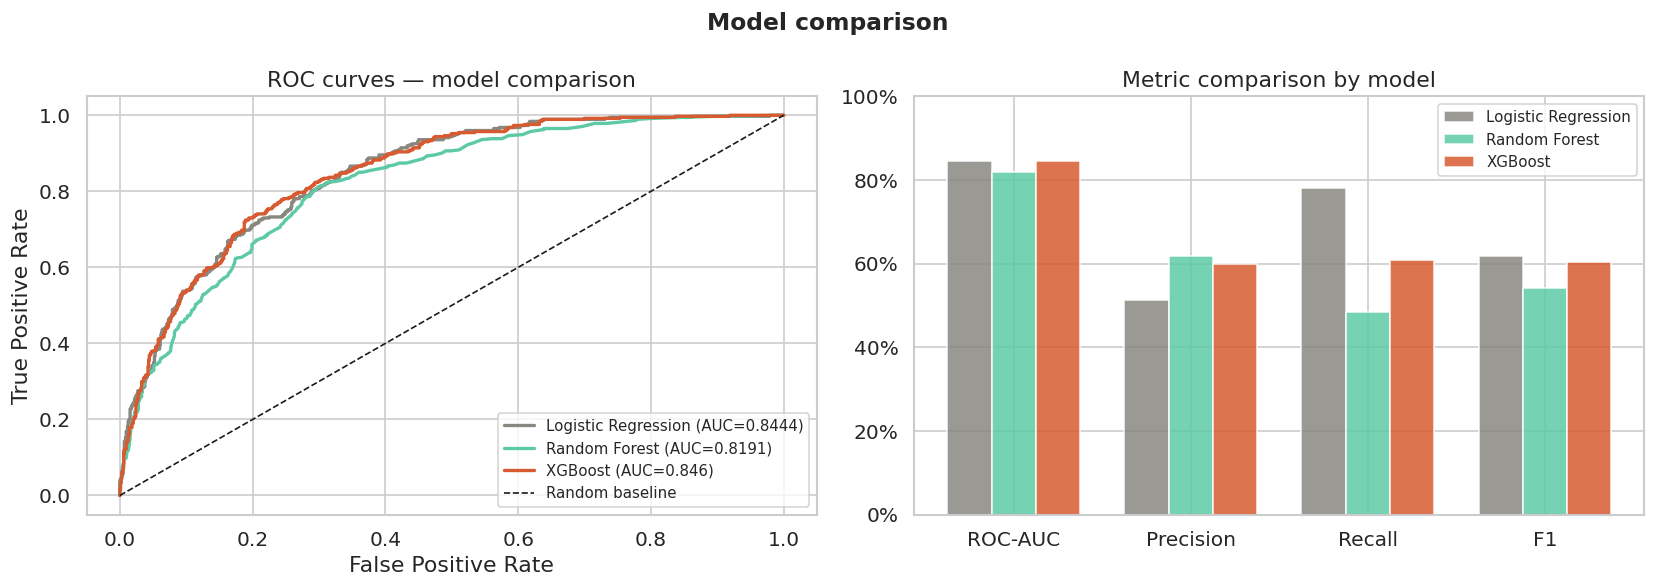

In [10]:
# ROC curves — all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#888780', 'Random Forest': '#5DCAA5', 'XGBoost': '#D85A30'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']})",
                 color=colors[name], linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves — model comparison')
axes[0].legend(fontsize=9)

# Bar chart comparison
metrics = ['roc_auc', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.25

for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = axes[1].bar(x + i * width, vals, width, label=name, color=list(colors.values())[i], alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['ROC-AUC', 'Precision', 'Recall', 'F1'])
axes[1].set_title('Metric comparison by model')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Model comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/06_model_comparison.png', bbox_inches='tight')
plt.show()

## 7. Threshold optimisation

The default threshold of 0.5 is rarely optimal for imbalanced problems. 
We find the threshold that maximises F1 for the churn class.

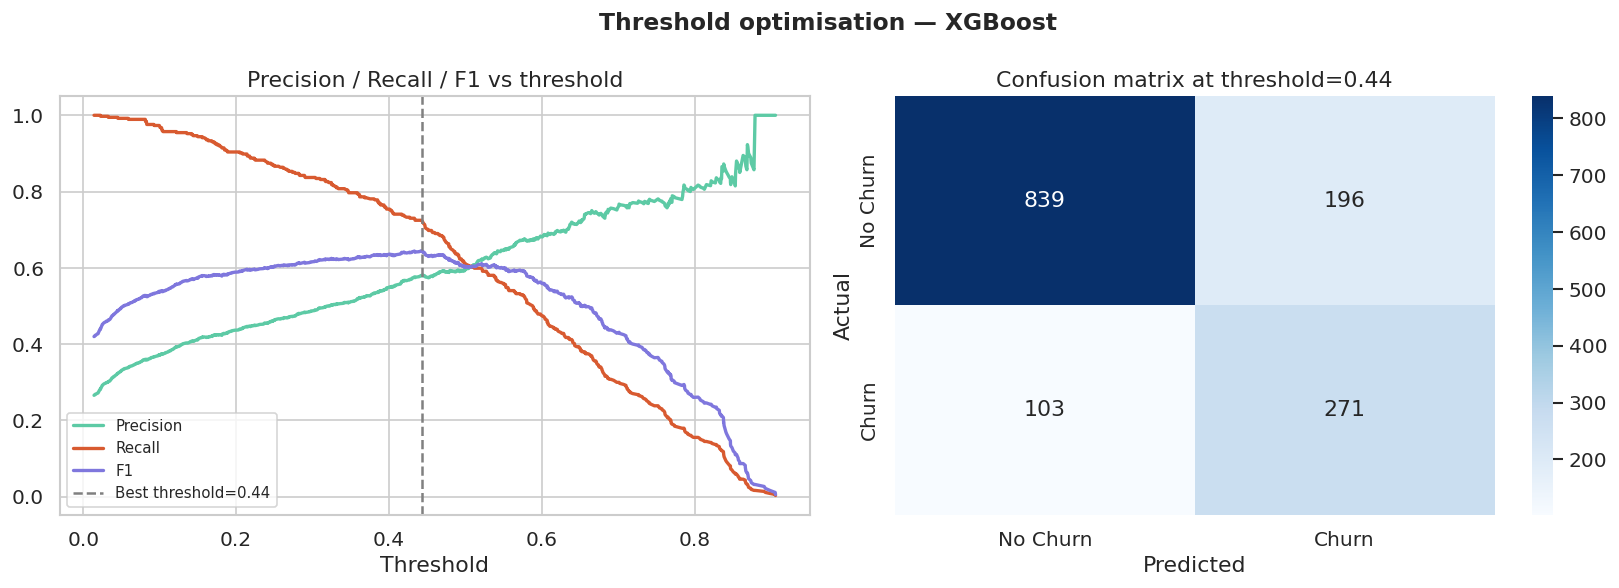

Best model: XGBoost
Optimal threshold: 0.44

              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      1035
       Churn       0.58      0.72      0.64       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.79      1409



In [11]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_res = results[best_model_name]
y_prob_best = best_res['y_prob']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions[:-1], label='Precision', color='#5DCAA5', linewidth=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', color='#D85A30', linewidth=2)
axes[0].plot(thresholds, f1_scores[:-1], label='F1', color='#7F77DD', linewidth=2)
axes[0].axvline(x=best_threshold, color='gray', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision / Recall / F1 vs threshold')
axes[0].legend(fontsize=9)

# Confusion matrix at best threshold
y_pred_opt = (y_prob_best >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title(f'Confusion matrix at threshold={best_threshold:.2f}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle(f'Threshold optimisation — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/07_threshold_optimisation.png', bbox_inches='tight')
plt.show()

print(f'Best model: {best_model_name}')
print(f'Optimal threshold: {best_threshold:.2f}')
print()
print(classification_report(y_test, y_pred_opt, target_names=['No Churn', 'Churn']))

## 8. Save best model

Save the best pipeline — includes the full preprocessing + model — ready for the API.

In [12]:
import json, os

best_pipe = best_res['pipe']

os.makedirs('../results', exist_ok=True)
with open('../results/best_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)

# Save metrics to JSON
metrics_out = {
    'best_model': best_model_name,
    'optimal_threshold': round(float(best_threshold), 3),
    'test_metrics': {
        name: {k: v for k, v in res.items() if k not in ['pipe', 'y_prob']}
        for name, res in results.items()
    }
}

os.makedirs('../results/metrics', exist_ok=True)
with open('../results/metrics/model_comparison.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print(f'Best model saved → results/best_model.pkl')
print(f'Metrics saved    → results/metrics/model_comparison.json')
print()
print('Summary:')
print(f'  Model:     {best_model_name}')
print(f'  ROC-AUC:   {best_res["roc_auc"]}')
print(f'  Precision: {best_res["precision"]}')
print(f'  Recall:    {best_res["recall"]}')
print(f'  Threshold: {best_threshold:.2f}')
print()
print('Next step: notebooks/03_business_impact.ipynb')

Best model saved → results/best_model.pkl
Metrics saved    → results/metrics/model_comparison.json

Summary:
  Model:     XGBoost
  ROC-AUC:   0.846
  Precision: 0.5984
  Recall:    0.6096
  Threshold: 0.44

Next step: notebooks/03_business_impact.ipynb
